# TA Features Experiment — Performance & SHAP Analysis

**Purpose**: Evaluate the TA-features experiment artifact (saved by `ta_features_training.ipynb`).  
Runs the same 7-fold walk-forward, SHAP analysis, and Dir AUC as the final model performance notebook.

> Run this notebook **after** `ta_features_training.ipynb` has saved an artifact with `SAVE = True`.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[2]          # project root (3 levels up from final_model_experiment/)
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments'

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'  # experiment artifacts

print(f'ROOT: {ROOT}')
print(f'Artifact dir: {ARTIFACT_DIR}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/model_experiments/final_model_experiment/artifacts


## 1. Load & Verify Artifact

In [2]:
import pickle, json

pkl_files = sorted(ARTIFACT_DIR.glob('ta_features_*.pkl'), key=lambda f: f.stat().st_mtime)
assert pkl_files, (
    'No TA-features artifact found in artifacts/.\n'
    'Run ta_features_training.ipynb first and set SAVE = True after reviewing results.'
)
pkl_path  = pkl_files[-1]   # most recently saved
json_path = pkl_path.with_suffix('.json')

with open(pkl_path, 'rb') as f:
    artifact = pickle.load(f)
with open(json_path) as f:
    meta = json.load(f)

model     = artifact['model']
features  = artifact['features']
TARGET    = artifact['target']
THRESHOLD = artifact['threshold']
label_map = artifact['label_map']
inv_map   = artifact['inverse_label_map']
BEST_PARAMS = artifact.get('best_params', dict(
    num_leaves=8, min_child_samples=40, n_estimators=120,
    learning_rate=0.05, feature_fraction=0.8, reg_alpha=0.2, reg_lambda=1.0,
))

print(f'Artifact    : {pkl_path.name}')
print(f'Combo       : {artifact.get("combo_name", "unknown")}')
print(f'TA added    : {artifact.get("ta_features_added", [])}')
print(f'Features    : {len(features)}')
print(f'Target      : {TARGET}')
print(f'Threshold   : \u00b1{THRESHOLD*100:.1f}%')
print(f'Best params : {BEST_PARAMS}')


Artifact    : ta_features_l-2026-04-22.pkl
Combo       : L (E+rsqr60)
TA added    : ['td_wvma_5d', 'td_beta_20d', 'td_rsqr_60d']
Features    : 33
Target      : target_excess_xfn_5d
Threshold   : ±0.3%
Best params : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 4, 'min_child_samples': 40, 'n_estimators': 200}


## 2. Load Dataset

In [3]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset: {len(df)} rows, {df["date"].min().date()} – {df["date"].max().date()}')
print(f'Missing features: {[f for f in features if f not in df.columns]}')

Dataset: 1285 rows, 2021-02-25 – 2026-04-09
Missing features: []


## 3. Walk-Forward Evaluation

In [4]:
import lightgbm as lgb
from sklearn.metrics import f1_score

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))


def fit_predict(train_df, test_df):
    x_tr = train_df[features].fillna(train_df[features].median())
    y_tr = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1,
        **BEST_PARAMS,
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values           # raw continuous excess return
    preds_enc = clf.predict(x_te)
    preds = np.array([inv_map[p] for p in preds_enc])
    proba = clf.predict_proba(x_te)  # shape (n,3): cols = [P(label=-1), P(label=0), P(label=+1)]
    return clf, preds, y_te_cls, y_te_cont, proba


from sklearn.metrics import roc_auc_score


def offset_metrics(preds, y_true_cls, y_true_cont, dates, proba=None):
    """
    active_asa uses the CONTINUOUS excess return for sign comparison (matching
    run_redesign_experiments.py). This means even a neutral-labeled return that
    moves in the predicted direction counts as directionally correct — the right
    behaviour for a signal-detector framing.

    dir_auc: average of one-vs-rest AUC for the outperform (+1) and underperform (-1)
    signals, computed from class probabilities. proba columns follow label_map:
    col 0 = P(label=-1), col 1 = P(label=0), col 2 = P(label=+1).
    Averaged over the same stride-5 offsets for consistency.
    """
    rows = []
    for off in OFFSETS:
        idx = np.arange(off, len(dates), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        valid_active = active.sum() > 0

        # Dir AUC — gracefully skip offset if a class is absent (can happen in v7's 63-day window)
        d_auc = np.nan
        if proba is not None:
            pb = proba[idx]
            try:
                auc_long  = roc_auc_score((y_cls == 1).astype(int),  pb[:, 2])
                auc_short = roc_auc_score((y_cls == -1).astype(int), pb[:, 0])
                d_auc = (auc_long + auc_short) / 2
            except ValueError:
                pass  # constant class in this offset — leave as nan

        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean()) if valid_active else np.nan,
            'dir_auc':    d_auc,
        })
    r = pd.DataFrame(rows).mean()
    return r


fold_results = []
fold_models  = []
fold_shap_dfs = []

# ── Fold date summary ──────────────────────────────────────────────────────────
print("=== Walk-Forward Fold Dates ===")
print(f"{'Fold':<6} {'Train start':<14} {'Train end':<14} {'Test start':<14} {'Test end':<14} {'Test days':>10}")
print("-" * 72)
train_start_global = df[df[TARGET].notna()]['date'].min().date()
for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te_mask = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    n_test = te_mask.sum()
    print(f"{fold_id:<6} {str(train_start_global):<14} {train_end:<14} {test_start:<14} {test_end:<14} {n_test:>10}")
print("-" * 72)
print(f"  Dataset range : {str(train_start_global)} → {df[df[TARGET].notna()]['date'].max().date()}")
print(f"  Out-of-sample : {E10_FOLDS[0][2]} → {E10_FOLDS[-1][3]}")
print()

for fold_id, train_end, test_start, test_end in E10_FOLDS:
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    train_df, test_df = df[train_mask], df[test_mask]

    clf, preds, y_true_cls, y_true_cont, proba = fit_predict(train_df, test_df)
    m = offset_metrics(preds, y_true_cls, y_true_cont, test_df['date'].values, proba=proba)

    # SHAP on test set
    explainer  = shap.TreeExplainer(clf)
    x_te_clean = test_df[features].fillna(train_df[features].median())
    shap_vals  = explainer.shap_values(x_te_clean)
    # Handle both old API (list of arrays per class) and new API (3D array)
    if isinstance(shap_vals, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        sv = np.array(shap_vals)
        if sv.ndim == 3:
            mean_abs = np.abs(sv).mean(axis=(0, 2)) if sv.shape[-1] == 3 else np.abs(sv).mean(axis=(0, 1))
        else:
            mean_abs = np.abs(sv).mean(axis=0)
    shap_ser   = pd.Series(mean_abs, index=features, name=fold_id)
    fold_shap_dfs.append(shap_ser)

    fold_results.append({
        'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
        'train_end': train_end, 'test_start': test_start, 'test_end': test_end,
        **m.to_dict()
    })
    fold_models.append(clf)
    print(f'Fold {fold_id}  mean_acc={m.mean_acc:.3f}  asa={m.active_asa:.3f}  cov={m.active_cov:.3f}  dir_auc={m.dir_auc:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print('\nDone.')

=== Walk-Forward Fold Dates ===
Fold   Train start    Train end      Test start     Test end        Test days
------------------------------------------------------------------------
v1     2021-02-25     2022-12-30     2023-01-10     2023-06-30            121
v2     2021-02-25     2023-06-30     2023-07-11     2023-12-29            119
v3     2021-02-25     2023-12-29     2024-01-09     2024-06-28            121
v4     2021-02-25     2024-06-28     2024-07-09     2024-12-31            121
v5     2021-02-25     2024-12-31     2025-01-09     2025-06-30            120
v6     2021-02-25     2025-06-30     2025-07-09     2025-12-31            121
v7     2021-02-25     2025-12-31     2026-01-09     2026-04-09             63
------------------------------------------------------------------------
  Dataset range : 2021-02-25 → 2026-04-09
  Out-of-sample : 2023-01-10 → 2026-04-09



Fold v1  mean_acc=0.462  asa=0.615  cov=0.925  dir_auc=0.601


Fold v2  mean_acc=0.436  asa=0.582  cov=0.841  dir_auc=0.655


Fold v3  mean_acc=0.504  asa=0.628  cov=0.958  dir_auc=0.426


Fold v4  mean_acc=0.479  asa=0.558  cov=0.975  dir_auc=0.638


Fold v5  mean_acc=0.408  asa=0.591  cov=0.692  dir_auc=0.573


Fold v6  mean_acc=0.470  asa=0.612  cov=0.959  dir_auc=0.572


Fold v7  mean_acc=0.413  asa=0.559  cov=0.983  dir_auc=0.524

Done.


## 4. Performance Summary

In [5]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa', 'dir_auc']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
print('\n=== 7-Fold Mean ===')
print(f'  Mean accuracy        : {means.mean_acc:.3f}')
print(f'  Macro F1             : {means.macro_f1:.3f}')
print(f'  Active coverage      : {means.active_cov:.3f}')
print(f'  Active sign accuracy : {means.active_asa:.3f}')
print(f'  Dir AUC             : {means.dir_auc:.3f}  (avg one-vs-rest AUC for ±1 signals, stride-5 averaged)')

# DirAcc metrics
results_df['DirAcc_strict']   = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                  + 0.5 * (1 - results_df['active_cov']))

print('\n=== DirAcc Metrics (7-fold means) ===')
print(f'  DirAcc_strict   (active-weighted) : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 (abstain=50/50)  : {results_df["DirAcc_abstain50"].mean():.3f}')
print(f'  Naive max-bias baseline           : ~0.520  (long-share on excess-return target)')

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa,dir_auc
fold,,,,,,,
v1,464,121,0.462,0.356,0.925,0.615,0.601
v2,590,119,0.436,0.388,0.841,0.582,0.655
v3,714,121,0.504,0.266,0.958,0.628,0.426
v4,840,121,0.479,0.381,0.975,0.558,0.638
v5,966,120,0.408,0.377,0.692,0.591,0.573
v6,1091,121,0.470,0.375,0.959,0.612,0.572
v7,1217,63,0.413,0.303,0.983,0.559,0.524



=== 7-Fold Mean ===
  Mean accuracy        : 0.453
  Macro F1             : 0.349
  Active coverage      : 0.905
  Active sign accuracy : 0.592
  Dir AUC             : 0.570  (avg one-vs-rest AUC for ±1 signals, stride-5 averaged)

=== DirAcc Metrics (7-fold means) ===
  DirAcc_strict   (active-weighted) : 0.536
  DirAcc_abstain50 (abstain=50/50)  : 0.583
  Naive max-bias baseline           : ~0.520  (long-share on excess-return target)


## 5. SHAP Global Feature Importance

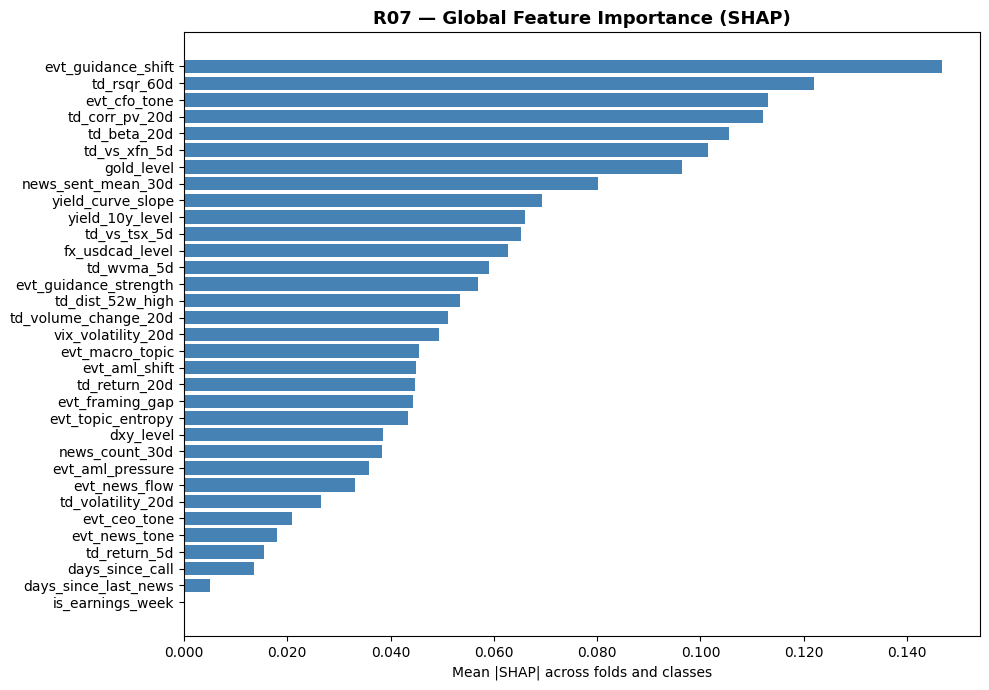


Top-10 features by mean |SHAP|:
evt_guidance_shift    0.146804
td_rsqr_60d           0.121996
evt_cfo_tone          0.113130
td_corr_pv_20d        0.112071
td_beta_20d           0.105582
td_vs_xfn_5d          0.101522
gold_level            0.096453
news_sent_mean_30d    0.080156
yield_curve_slope     0.069265
yield_10y_level       0.065985


In [6]:
shap_df   = pd.DataFrame(fold_shap_dfs)           # (7 folds, 30 features)
global_imp = shap_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(global_imp.index[::-1], global_imp.values[::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP| across folds and classes')
ax.set_title('R07 — Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.show()

print('\nTop-10 features by mean |SHAP|:')
print(global_imp.head(10).to_string())

## 6. SHAP Stability Across Folds (Heatmap)

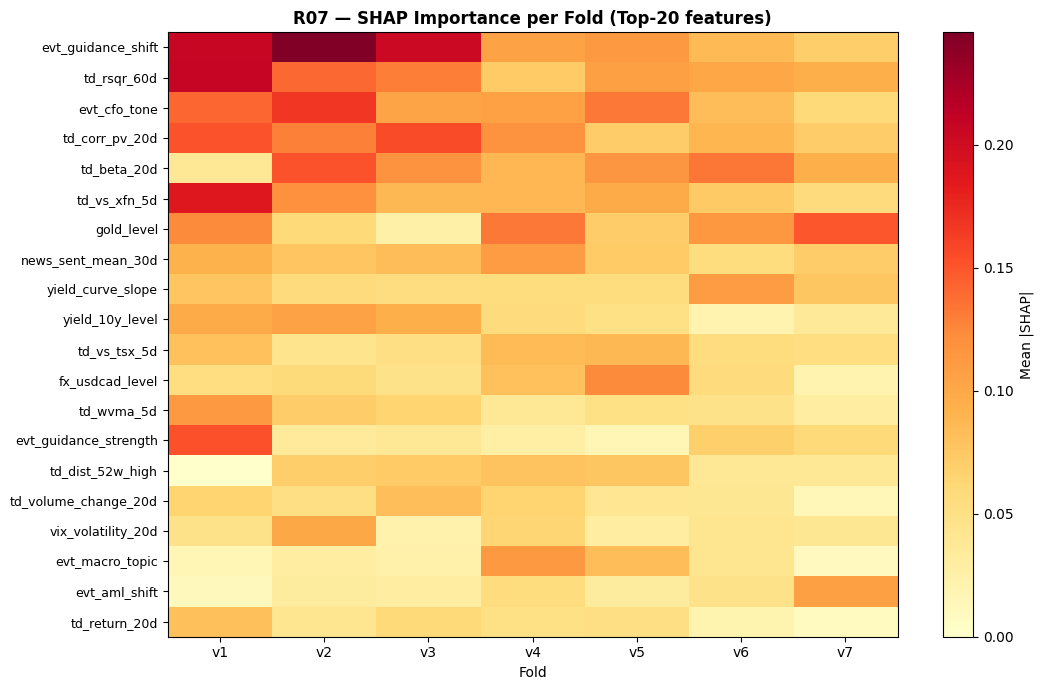

In [7]:
# Rank features by global mean, show top 20
top20 = global_imp.head(20).index.tolist()
heat  = shap_df[top20].T   # (features, folds)

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f'v{i+1}' for i in range(len(heat.columns))], fontsize=10)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20, fontsize=9)
ax.set_xlabel('Fold')
ax.set_title('R07 — SHAP Importance per Fold (Top-20 features)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout()
plt.show()

## 7. SHAP Beeswarm on Final Model (trained on all data)

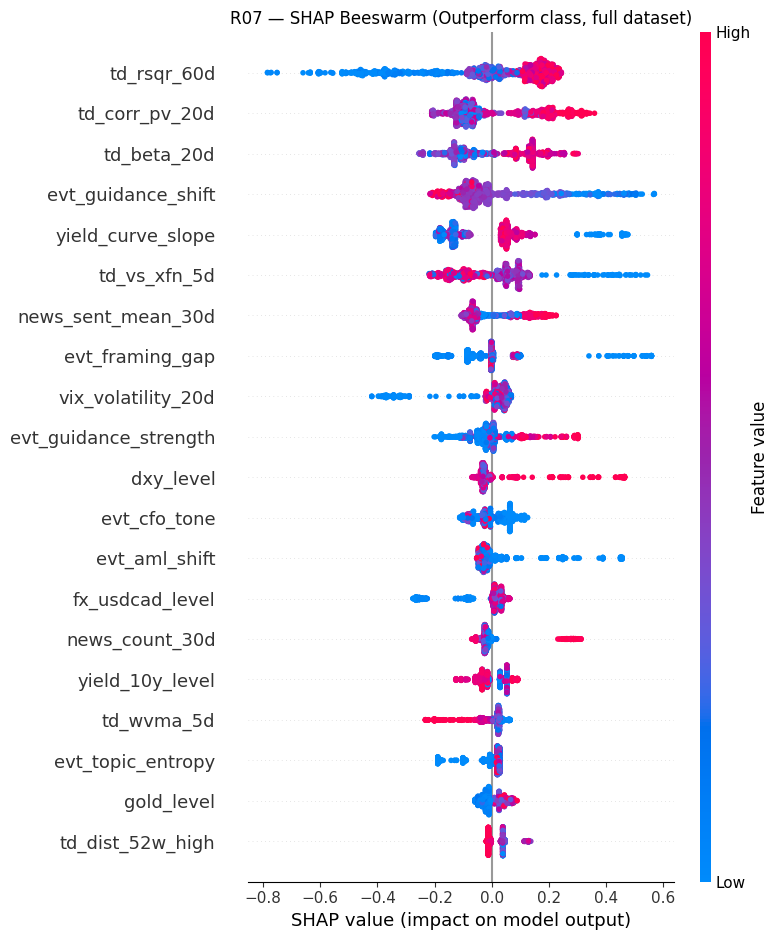

In [8]:
# Use the locked final model (trained on full dataset) for beeswarm
df_clean = df.dropna(subset=[TARGET])
x_all = df_clean[features].fillna(df_clean[features].median())

explainer_final = shap.TreeExplainer(model)
shap_vals_final = explainer_final.shap_values(x_all)

# Extract outperform class (label +1, encoded as index 2)
# Handle both old API (list per class) and new API (3D array)
if isinstance(shap_vals_final, list):
    sv_outperform = shap_vals_final[2]
else:
    sv = np.array(shap_vals_final)
    sv_outperform = sv[:, :, 2] if sv.ndim == 3 and sv.shape[-1] == 3 else sv[2]

shap.summary_plot(
    sv_outperform, x_all,
    feature_names=features,
    plot_type='dot',
    max_display=20,
    show=False,
)
plt.title('R07 — SHAP Beeswarm (Outperform class, full dataset)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Feature List (Audit)

All features used in this TA-features experiment artifact, grouped by block.

In [9]:
# Print feature list from the loaded artifact (dynamic — works for any combo)
print(f'Total features in artifact: {len(features)}\n')
ta_added = artifact.get('ta_features_added', [])

# Group into: baseline block and TA additions
baseline_feats = [f for f in features if f not in ta_added]
print(f'Baseline features ({len(baseline_feats)}):')
for f in baseline_feats:
    print(f'  {f}')
if ta_added:
    print(f'\nTA features added ({len(ta_added)}):')
    for f in ta_added:
        print(f'  {f}  ← new')


Total features in artifact: 33

Baseline features (30):
  td_return_5d
  td_return_20d
  td_volatility_20d
  td_vs_xfn_5d
  td_vs_tsx_5d
  td_corr_pv_20d
  td_volume_change_20d
  td_dist_52w_high
  yield_curve_slope
  yield_10y_level
  vix_volatility_20d
  dxy_level
  gold_level
  fx_usdcad_level
  news_sent_mean_30d
  news_count_30d
  days_since_last_news
  days_since_call
  is_earnings_week
  evt_ceo_tone
  evt_cfo_tone
  evt_framing_gap
  evt_aml_pressure
  evt_aml_shift
  evt_guidance_strength
  evt_guidance_shift
  evt_macro_topic
  evt_topic_entropy
  evt_news_tone
  evt_news_flow

TA features added (3):
  td_wvma_5d  ← new
  td_beta_20d  ← new
  td_rsqr_60d  ← new
